In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib


In [2]:
# Load trained SARIMA model
sarima_model = joblib.load("../models/sarima_model.pkl")

# Load original dataset
df = pd.read_csv("../data set/AirPassengers.csv")
df.rename(columns={"#Passengers":"Passengers"}, inplace=True)

In [3]:
# Forecast next 12 months
forecast_log = sarima_model.forecast(steps=12)
forecast = np.exp(forecast_log)

print("Future Forecast")
print(forecast)

Future Forecast
132    419.908927
133    399.523583
134    466.708698
135    454.426879
136    473.310256
137    548.264548
138    623.169296
139    631.411589
140    526.952867
141    462.509573
142    406.554092
143    451.697027
Name: predicted_mean, dtype: float64


In [4]:
# Create future month labels
last_date = pd.to_datetime(df["Month"].iloc[-1])

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

future_df = pd.DataFrame({
    "Month":future_dates.strftime("%Y-%m"),
    "Predicted_Passengers":forecast.values
})

print(future_df)


      Month  Predicted_Passengers
0   1961-01            419.908927
1   1961-02            399.523583
2   1961-03            466.708698
3   1961-04            454.426879
4   1961-05            473.310256
5   1961-06            548.264548
6   1961-07            623.169296
7   1961-08            631.411589
8   1961-09            526.952867
9   1961-10            462.509573
10  1961-11            406.554092
11  1961-12            451.697027


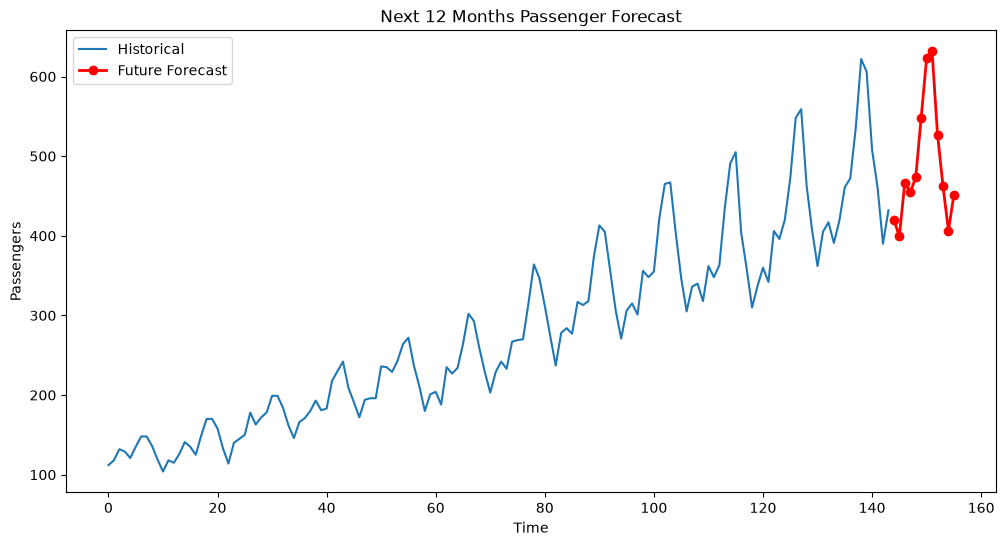

In [6]:
# Save predictions
future_df.to_csv("../data set/future_predictions.csv", index=False)

plt.figure(figsize=(12,6))
plt.plot(df["Passengers"],label="Historical")
future_index = range(len(df), len(df)+12)
plt.plot(future_index,forecast,color="red",marker="o",linewidth=2,label="Future Forecast")
plt.xlabel("Time")
plt.ylabel("Passengers")
plt.title("Next 12 Months Passenger Forecast")
plt.legend()
plt.show()